In [11]:
import os
import glob
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [12]:
# =============
# Data Load

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

num_points = 5000  # Número de puntos en cada espectro, para interpolar los datos que le pasamos

# Buscar todos los archivos que comiencen con "spectra_data_100k" en la carpeta "data"
data_files = glob.glob('data/spectra_data_fullbig*.pkl')
data_files = sorted(data_files)  # Ordena para garantizar un orden consistente

# Inicializar el diccionario donde se acumularán los datos
spectra_data = {}

# Cargar y combinar los datos de cada archivo encontrado
for file in data_files:
    with open(file, 'rb') as f:
        data_part = pickle.load(f)
        print(f"Archivo cargado: {file}")
    spectra_data.update(data_part)

print(f"Se han cargado {len(spectra_data)} espectros a partir de {len(data_files)} archivos.")

Usando dispositivo: cuda
Archivo cargado: data\spectra_data_fullbig.pkl
Se han cargado 50000 espectros a partir de 1 archivos.


In [13]:
# =============
# Model Evaluation
 
# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Número de puntos en cada espectro
num_points = 5000

# Definición del modelo que combina CNN y atención para resaltar las líneas de emisión
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # Después de las convoluciones, la dimensión embebida es 256
        self.embed_dim = 256
        
        # Se utiliza self-attention sobre la secuencia de características
        self.attention = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=4, batch_first=True)
        
        # Calcular el tamaño de salida después de las capas convolucionales (5 capas de MaxPool1d con kernel_size=2)
        conv_output_size = num_points // 32
        
        # Capas finales para la regresión del redshift
        self.fc_layers = nn.Sequential(
            nn.Linear(self.embed_dim * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x tiene forma (batch_size, 2, num_points)
        features = self.conv_layers(x)             # Resultado: (batch_size, 256, seq_length)
        features = features.permute(0, 2, 1)         # Reordenar a (batch_size, seq_length, embed_dim)
        # Aplicar self-attention (usando las mismas características como query, key y value)
        attn_output, _ = self.attention(features, features, features)
        # Aplanar la salida para la capa fully connected
        attn_output = attn_output.contiguous().view(attn_output.size(0), -1)
        out = self.fc_layers(attn_output)
        return out

# Instanciar el modelo y moverlo a GPU
modelCNN = CNN(num_points).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(modelCNN.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

Usando dispositivo: cuda


In [14]:
# Cargar el modelo
modelCNN = CNN(num_points).to(device)
checkpoint = torch.load('storage/modelCNN_UPD5_100ktest.pth', weights_only=False)
modelCNN.load_state_dict(checkpoint['model_state_dict'])

# Extraer los datos del diccionario
file_names = list(spectra_data.keys())
fluxes = [spectra_data[f]["flux"] for f in file_names]
wavelength = [spectra_data[f]["wavelength"] for f in file_names]
redshifts = [spectra_data[f]["redshift"] for f in file_names]

# Concatenar flujo y longitud de onda como entrada al modelo
X = np.stack([fluxes, wavelength], axis=1)  # Ahora tiene 10000 características por muestra
yreal = np.array(redshifts)

# Normalización utilizando el scaler previamente ajustado
nsamples, nchannels, npoints = X.shape
X = X.reshape(nsamples, -1)

# Cargar el scaler preajustado guardado con pickle
with open('extra/scaler_modelCNN_UPD4_100ktest.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Transformar los datos sin volver a hacer fit
X = scaler.transform(X)
X = X.reshape(nsamples, nchannels, npoints)

# Convertir a tensor y mover a GPU si es necesario
x_test_tensor = torch.tensor(X, dtype=torch.float32).to(device)

# Evaluar el modelo por batches
batch_size = 64  # Ajusta este valor según tu GPU
n_samples = x_test_tensor.size(0)

all_preds = []
modelCNN.eval()
with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        x_batch = x_test_tensor[i : i + batch_size]
        preds = modelCNN(x_batch).cpu().numpy()
        all_preds.append(preds)

ypredicted = np.concatenate(all_preds, axis=0)

# Calcular la correlación lineal entre las etiquetas reales y las predichas
lincorr = np.corrcoef(yreal, ypredicted.squeeze())
print(f"Correlación lineal: {lincorr[0, 1]}")
print(f"Número de muestras: {len(yreal)}")

Correlación lineal: 0.484981154011823
Número de muestras: 50000


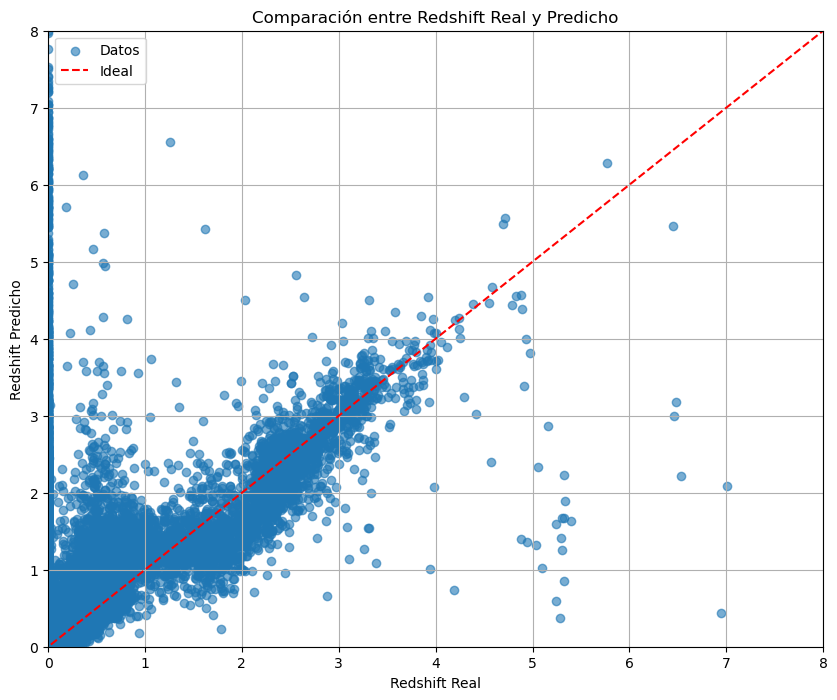

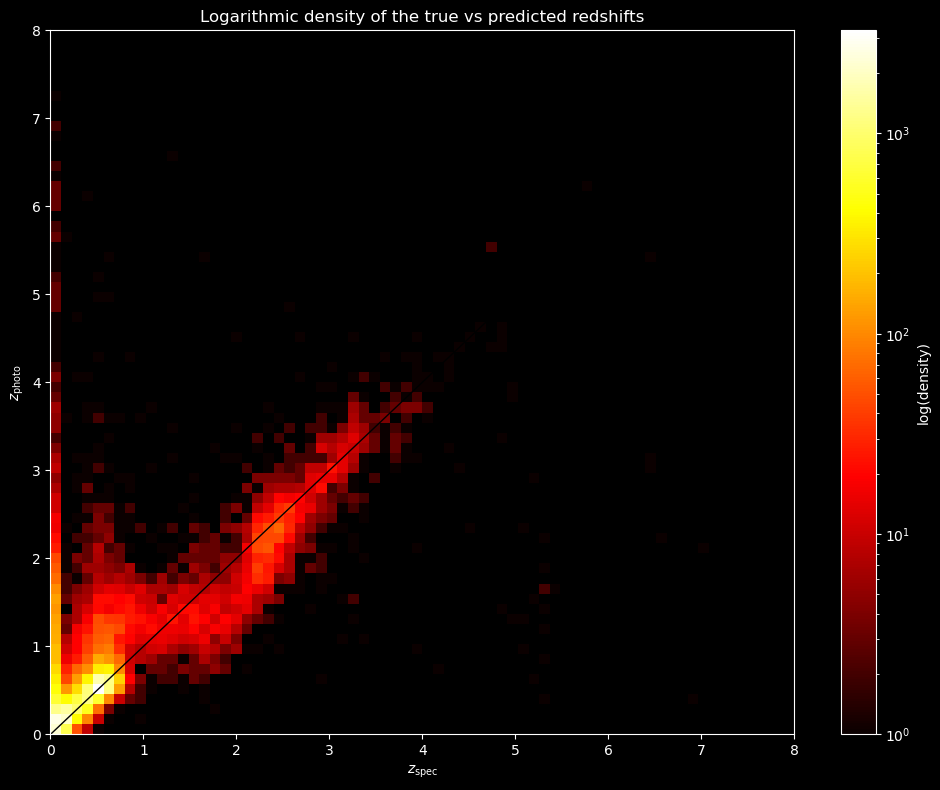

In [15]:
plt.rcdefaults()
plt.figure(figsize=(10, 8))
plt.scatter(yreal, ypredicted, alpha=0.6, label='Datos')
plt.xlabel('Redshift Real')
plt.ylabel('Redshift Predicho')
plt.title('Comparación entre Redshift Real y Predicho')
# Añadir la línea ideal (y=x)
min_val = min(yreal.min(), ypredicted.min())
max_val = max(yreal.max(), ypredicted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
plt.legend()
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.show()







# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 0, 8
y_min, y_max = 0, 8

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

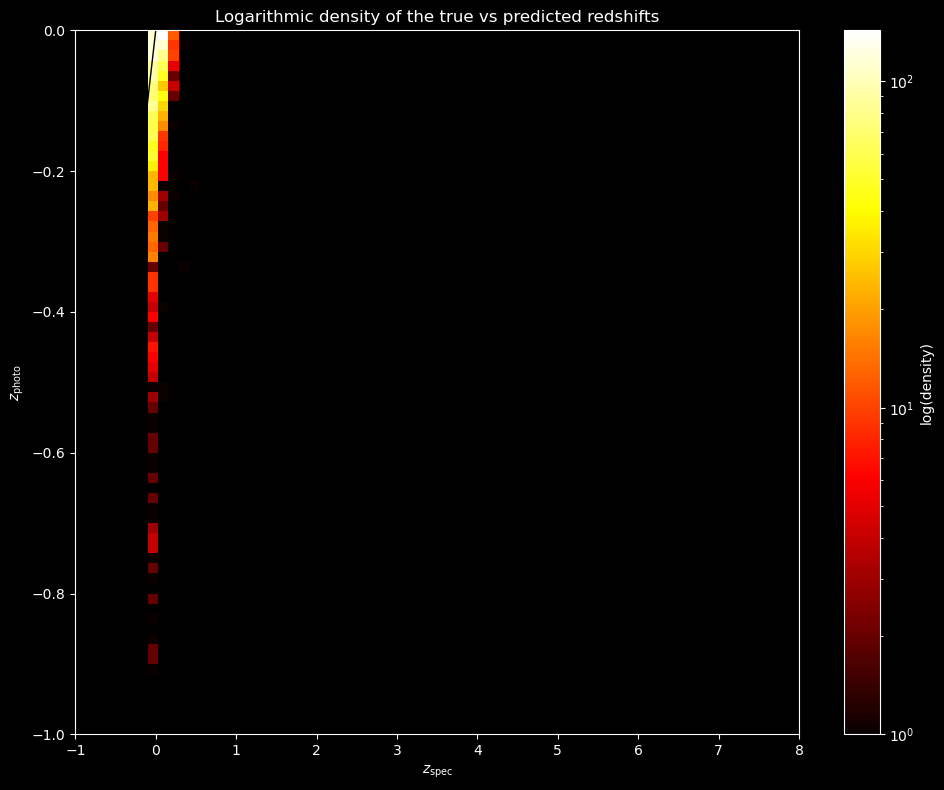

In [16]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = -1, 8
y_min, y_max = -1, 0

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

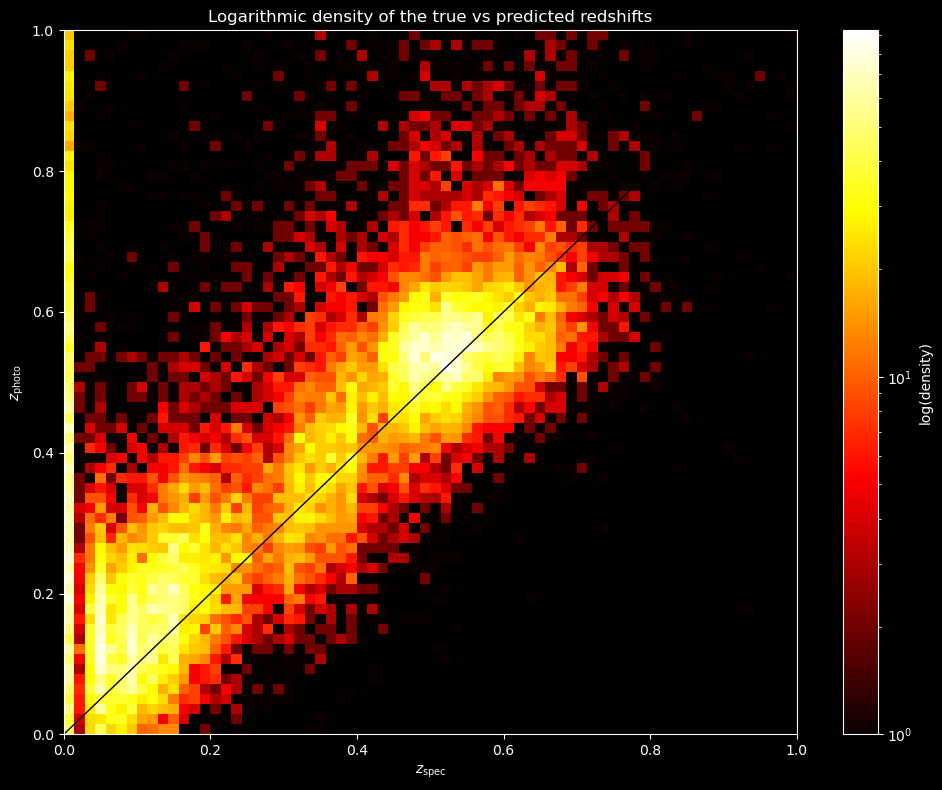

In [17]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 0, 1
y_min, y_max = 0, 1

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

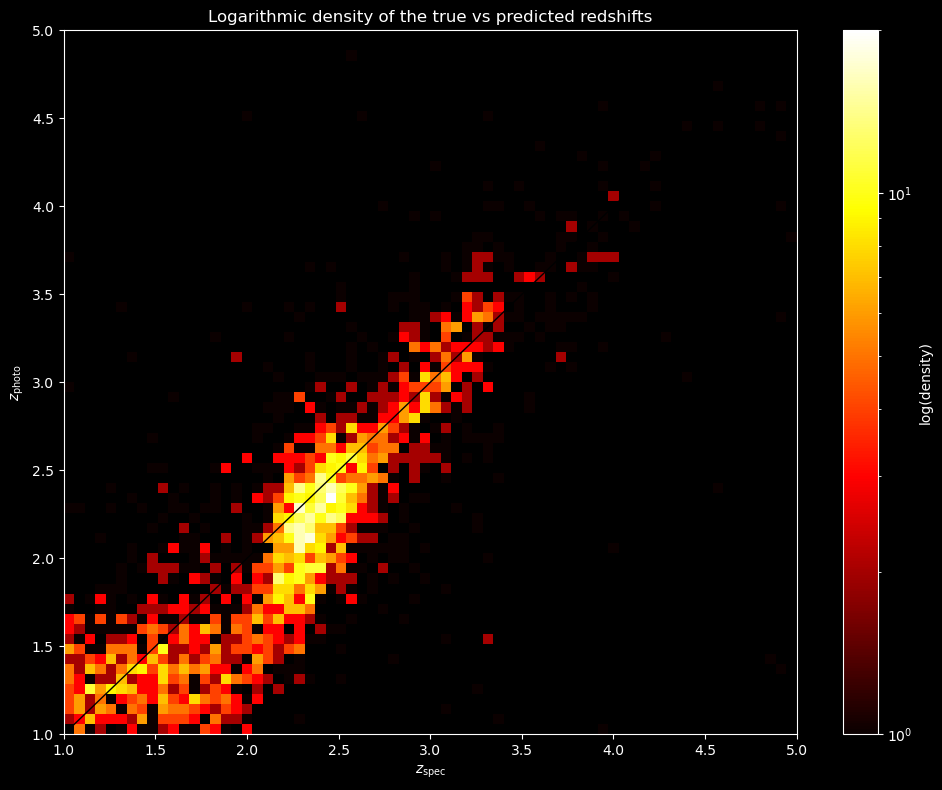

In [18]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 1, 5
y_min, y_max = 1, 5

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

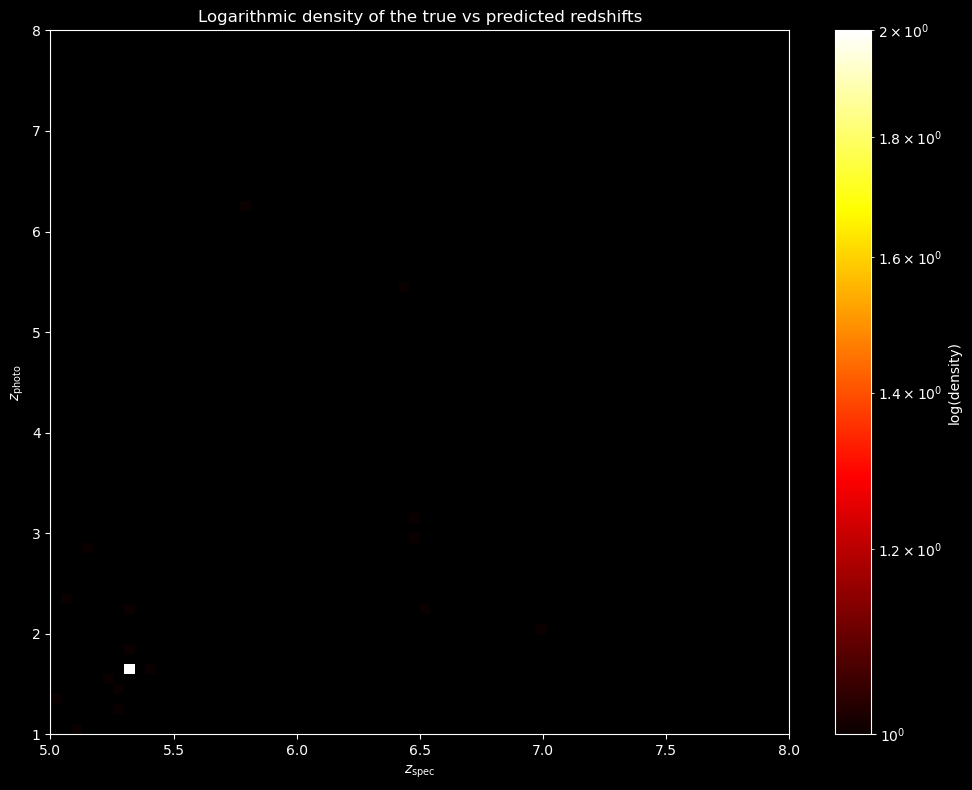

In [19]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 5, 8
y_min, y_max = 1, 8

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()